## 1. Project Path Configuration.
Add the project root directory to Python’s search path (`sys.path`)  
to ensure that local packages under the `src/` folder (such as `dataset.py`, `transforms.py`, and `loaders.py`)  
can be imported correctly from within the `notebooks/` directory.
#### Rationale:
- Keep imports consistent across all notebooks (`01_data_eda` --> `04_evaluation_results`).  
- Enable reuse of modular code without duplication.  
- Maintain reproducibility and a clean experiment structure.

In [2]:
# Add project root to Python path so `src` can be imported.
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()  # One level up from /notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root added to path: {PROJECT_ROOT}')
print("Python path updated to include /src\n")

Project root added to path: /lab/px/msc-sept-24-ft-cohort-capstone-chrisanich
Python path updated to include /src



## 2. Library Imports and Environment Setup.
Import all essential libraries required for evaluation, including NumPy, Pandas, Matplotlib, PyTorch, and scikit-learn.  
Define the main project directories for data, experiments, and reports, ensuring that all output folders (figures and tables)  
exist before execution. Detect the available computation device (GPU or CPU) to guarantee consistent evaluation behaviour  
across different hardware environments.
#### Rationale:
- Load the core Python and deep learning libraries needed for model evaluation and visualisation.  
- Maintain directory structure consistency across notebooks to simplify reproducibility.  
- Automatically create missing output folders to prevent runtime errors when saving results.  
- Select the available hardware device automatically to ensure portability between systems.

In [3]:
# Standard library imports.
import sys
from pathlib import Path
import json, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch and torchvision imports.
import torch
import torch.nn as nn
from torchvision import models

# Scikit-learn metrics for evaluation.
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Define directory constants (consistent with 01/02/03 notebooks).
DATA_DIR        = PROJECT_ROOT / "data"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
POOLS_DIR       = EXPERIMENTS_DIR / "pools"
CHECKPOINTS_DIR = EXPERIMENTS_DIR / "checkpoints"
RESULTS_DIR     = EXPERIMENTS_DIR / "results"
REPORTS_DIR     = PROJECT_ROOT / "reports"
FIG_DIR         = REPORTS_DIR / "figures"
TABLE_DIR       = REPORTS_DIR / "tables"

# Ensure output directories exist (create if needed).
for d in [FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Device selection.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Evaluation device: {DEVICE.upper()}")

Evaluation device: CUDA


## 3. Load Preprocessing Configuration.
Load the preprocessing configuration file (`preprocessing_config.json`) generated during the data exploration stage.  
Extract the image size, class mappings, and normalisation statistics for both ImageNet and CXR domains.  
Verify that the file exists before continuing, as it defines parameters needed for data loading,  
model reconstruction, and consistent evaluation across experiments.
#### Rationale:
- Ensure image size, labels, and normalisation match the training setup.  
- Maintain compatibility and reproducibility across notebooks.  
- Prevent evaluation errors from missing or mismatched preprocessing parameters.

In [4]:
# Load Preprocessing Config (classes and stats).
cfg_path = POOLS_DIR / "preprocessing_config.json"
if not cfg_path.exists():
    raise FileNotFoundError("Missing preprocessing_config.json (run 01_data_eda.ipynb).")

cfg = json.loads(cfg_path.read_text())

IMG_SIZE        = int(cfg["img_size"])
CLASS_TO_INDEX  = {k: int(v) for k, v in cfg["class_to_index"].items()}
INDEX_TO_CLASS  = {v: k for k, v in CLASS_TO_INDEX.items()}
IMAGENET_MEAN   = cfg["imagenet_mean"]
IMAGENET_STD    = cfg["imagenet_std"]
CXR_MEAN        = cfg["cxr_mean"]
CXR_STD         = cfg["cxr_std"]

print("Config loaded:")
print("- IMG_SIZE:", IMG_SIZE)
print("- Classes:", CLASS_TO_INDEX)

Config loaded:
- IMG_SIZE: 256
- Classes: {'Pneumonia': 0, 'TB': 1, 'Normal': 2}


## 4. Build Stratified Test Split
Create a fixed 10% test split from the unified dataset using stratified sampling to preserve class balance.  
Load the combined source pool and separate a reproducible subset for testing based on class labels.  
Save the resulting test split to disk to ensure consistency across evaluation runs and model comparisons.
#### Rationale:
- Maintain proportional representation of all classes in the test set.  
- Ensure reproducibility by using a fixed random seed.  
- Prevent data leakage between training, validation, and test subsets.  
- Store the test split for consistent evaluation across models and experiments.

In [5]:
# Build Test Split (Stratified 10%).
from sklearn.model_selection import StratifiedShuffleSplit
from src.dataset import CXRThreeClassDataset
from src.transforms import build_shared_transforms

# Load unified pool (relative paths + 'Source' + 'Class').
pool_csv = POOLS_DIR / "source_pool_rel.csv"
if not pool_csv.exists():
    raise FileNotFoundError("Missing source_pool_rel.csv (produce it in 01/02).")

source_pool_rel = pd.read_csv(pool_csv)

# Stratified 10% test split (fixed seed for reproducibility).
y = source_pool_rel["Class"]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=123)
test_idx = next(sss.split(source_pool_rel, y))[1]
test_items = source_pool_rel.iloc[test_idx].reset_index(drop=True)

print(f'Test set size: {len(test_items):,}')
print(test_items["Class"].value_counts().to_string())

# Persist the stratified 10% test split for reproducibility.
test_items.to_csv(POOLS_DIR / "test_split.csv", index=False)
print("\nSaved fixed 10% test split", (POOLS_DIR / "test_split.csv").relative_to(PROJECT_ROOT))

Test set size: 1,366
Class
TB           480
Pneumonia    468
Normal       418

Saved fixed 10% test split experiments/pools/test_split.csv


## 5. Model Builder
Rebuild each model architecture exactly as defined during training to ensure weight compatibility across checkpoints.  
Instantiate models without pretrained weights and replace their classifier heads to match the number of output classes.  
Use the same configuration as in `03_model_training.ipynb` to guarantee consistent layer structure during evaluation.
#### Rationale:
- Maintain architectural consistency between training and evaluation stages. 
- Prevent shape mismatches when loading trained weights from checkpoints.  
- Allow flexible evaluation of different architectures under the same experimental setup.  
- Enable fair performance comparison between pretrained (transfer learning) and custom CNN models.

In [6]:
# 4. Model Builder.
# Rebuilds model architectures exactly as defined in 03_model_training.ipynb.
# Used during evaluation to ensure weight compatibility across checkpoints.
# Each model is instantiated with no pretrained weights and its classifier head
# adjusted to match the number of output classes.

def build_model(model_name: str, num_classes: int, img_size: int = IMG_SIZE) -> nn.Module:
    """
    Create an empty model with the same structure used during training.
    Args:
        model_name (str): Architecture identifier ('mobilenet_v2', 'efficientnet_b0', etc.)
        num_classes (int): Number of output classes for the final layer.
        img_size (int): Input image size (default: from preprocessing config).
    Returns:
        torch.nn.Module: Reconstructed model ready to load weights.
    """
    if model_name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=None)
        m.classifier[1] = nn.Linear(m.last_channel, num_classes)
        arch_name = "MobileNetV2"
    elif model_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        arch_name = "EfficientNet-B0"
    elif model_name == "resnet50":
        m = models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        arch_name = "ResNet-50"
    elif model_name == "victorio":
        m = nn.Sequential(
            nn.Conv2d(3,16,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(),
            nn.Linear(32*4*4, num_classes)
        )
        arch_name = "Victorio CNN"
    else:
        raise ValueError(...)

    # Unified print after all branches.
    print(f'Model built: {arch_name} ({num_classes} classes, {img_size}px input)')
    return m

## 6. Evaluation Helpers.
Define helper functions to perform model evaluation and generate confusion matrix plots.  
Run inference on the test dataset to compute key performance metrics such as accuracy, precision, recall, F1-score,  
and AUROC (multi-class One-vs-Rest). Implement a separate plotting utility to visualise confusion matrices and  
export them as publication-quality figures.
#### Rationale:
- Automate quantitative evaluation of all trained models under a unified procedure.  
- Compute robust metrics for balanced and imbalanced classes using macro-averaging.  
- Include AUROC for probabilistic assessment of multi-class separability.  
- Generate reproducible visual summaries for reporting and model comparison.

In [7]:
# Evaluation Helpers (single pass, AUROC optional).
def evaluate_model(model: nn.Module, loader) -> dict:
    """Run inference over test loader; return metrics dict."""
    model.eval()
    all_logits, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            lbls = lbls.to(DEVICE)
            logits = model(imgs)
            preds = logits.argmax(1)

            all_logits.append(logits.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(lbls.cpu())

    logits = torch.cat(all_logits, dim=0).numpy()
    preds  = torch.cat(all_preds,  dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    # AUROC (multi-class OVR) requires probabilities.
    try:
        probs = (torch.from_numpy(logits)).softmax(dim=1).numpy()
        auroc = roc_auc_score(labels, probs, multi_class="ovr")
    except Exception:
        auroc = float("nan")

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auroc": float(auroc),
        "logits": logits,   # for optional downstream analysis
        "preds":  preds,
        "labels": labels,
    }

def plot_confusion(cm, labels, title, out_path):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".0f")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

## 7. Evaluate All Checkpoints.
Evaluate all trained model checkpoints across both ImageNet and CXR normalisation domains.  
Automatically detect each saved checkpoint, rebuild the corresponding architecture, and apply the correct  
normalisation statistics. Run inference on the fixed test split to compute accuracy, precision, recall,  
F1-score, and AUROC, and generate confusion matrix visualisations for each model.  
Finally, export aggregated metrics as JSON and CSV summaries for reporting and comparison.
#### Rationale:
- Ensure consistent and reproducible evaluation of all architectures under both normalisation regimes.  
- Automate checkpoint discovery and metric computation for efficient large-scale comparison.  
- Include multiple performance indicators to capture both class balance and discriminative ability.  
- Generate reusable evaluation summaries and figures for quantitative analysis and publication.

In [8]:
# 6) Evaluate all checkpoints (4 models × 2 norms).
from torch.utils.data import DataLoader

found_ckpts = sorted(CHECKPOINTS_DIR.glob("*_best.pt"))
if not found_ckpts:
    raise FileNotFoundError("No *_best.pt checkpoints found in experiments/checkpoints/")

summary = {}
class_names = [INDEX_TO_CLASS[i] for i in sorted(INDEX_TO_CLASS)]

print("Discovered checkpoints:")
for p in found_ckpts:
    print(" -", p.name)

for ckpt_path in found_ckpts:
    name = ckpt_path.stem  # e.g., mobilenet_v2_imagenet_best.
    # Parse model + normalisation from filename.
    parts = name.split("_")
    # Handles model names with underscores (mobilenet_v2) + suffix + "best".
    # Assume last token is "best" and the one before is norm suffix.
    norm_suffix = parts[-2]           # "imagenet" or "cxr".
    model_name  = "_".join(parts[:-2])# "mobilenet_v2", "efficientnet_b0", "resnet50", "victorio".

    # Pick the correct normalisation
    if norm_suffix == "imagenet":
        MEAN, STD, src = IMAGENET_MEAN, IMAGENET_STD, "ImageNet"
    else:
        MEAN, STD, src = CXR_MEAN, CXR_STD, "CXR"

    # Build eval transforms for this checkpoint.
    _, eval_transforms = build_shared_transforms(img_size=IMG_SIZE, mean=MEAN, std=STD)

    # Build test dataset/loader for this checkpoint (same images, matching stats)
    # (Rebuild absolute paths inside Dataset via its roots.)
    CHEXPERT_PATH = DATA_DIR / "chexpert"
    TBX11K_PATH   = DATA_DIR / "tbx11k"

    test_dataset = CXRThreeClassDataset(
        items=test_items,
        class_to_index=CLASS_TO_INDEX,
        transforms=eval_transforms,
        chexpert_root=CHEXPERT_PATH,
        tbx_root=TBX11K_PATH
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    print(f'\nEvaluating {name}  [{src}-normalised]  on {len(test_dataset)} test images…')

    # Rebuild architecture and load weights.
    model = build_model(model_name, num_classes=len(CLASS_TO_INDEX)).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    # Run evaluation.
    metrics = evaluate_model(model, test_loader)

    # Confusion matrix.
    cm = confusion_matrix(metrics["labels"], metrics["preds"])
    fig_path = FIG_DIR / f'{name}_confusion_matrix.png'
    plot_confusion(cm, class_names, f'Confusion Matrix: {name}', fig_path)

    print(
        f'  Acc={metrics["accuracy"]:.4f}  '
        f'Prec={metrics["precision"]:.4f}  '
        f'Rec={metrics["recall"]:.4f}  '
        f'F1={metrics["f1_score"]:.4f}  '
        f'AUROC={metrics["auroc"]:.4f}'
    )
    print(f"  Saved: {fig_path.name}")

    # Store summary (excluding bulky arrays).
    summary[name] = {
        "model": model_name,
        "normalisation": src,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "auroc": metrics["auroc"],
    }

# Persist JSON + CSV summaries.
summary_json = TABLE_DIR / "test_evaluation_summary.json"
with open(summary_json, "w") as f:
    json.dump(summary, f, indent=2)

summary_csv = TABLE_DIR / "test_evaluation_summary.csv"
with open(summary_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["name","model","normalisation","accuracy","precision","recall","f1_score","auroc"])
    for name, s in summary.items():
        writer.writerow([
            name, s["model"], s["normalisation"],
            f'{s["accuracy"]:.6f}', f'{s["precision"]:.6f}',
            f'{s["recall"]:.6f}', f'{s["f1_score"]:.6f}', f'{s["auroc"]:.6f}'
        ])

print("\nSummary written to:")
print(" -", summary_json.relative_to(PROJECT_ROOT))
print(" -", summary_csv.relative_to(PROJECT_ROOT))

# Print to notebook.
print("\nFinal Test Results")
print(f'{"Checkpoint":34s} | {"Norm":9s} | {"Acc":>6s} | {"Prec":>6s} | {"Rec":>6s} | {"F1":>6s} | {"AUROC":>7s}')
print("-"*80)
for name, s in sorted(summary.items()):
    print(f'{name:34s} | {s["normalisation"][:9]:9s} | {s["accuracy"]:.3f} | {s["precision"]:.3f} | {s["recall"]:.3f} | {s["f1_score"]:.3f} | {s["auroc"]:.3f}')

Discovered checkpoints:
 - efficientnet_b0_cxr_best.pt
 - efficientnet_b0_imagenet_best.pt
 - mobilenet_v2_cxr_best.pt
 - mobilenet_v2_imagenet_best.pt
 - resnet50_cxr_best.pt
 - resnet50_imagenet_best.pt
 - victorio_cxr_best.pt
 - victorio_imagenet_best.pt

Evaluating efficientnet_b0_cxr_best  [CXR-normalised]  on 1366 test images…
Model built: EfficientNet-B0 (3 classes, 256px input)
  Acc=0.9993  Prec=0.9993  Rec=0.9992  F1=0.9993  AUROC=1.0000
  Saved: efficientnet_b0_cxr_best_confusion_matrix.png

Evaluating efficientnet_b0_imagenet_best  [ImageNet-normalised]  on 1366 test images…
Model built: EfficientNet-B0 (3 classes, 256px input)
  Acc=0.9971  Prec=0.9971  Rec=0.9969  F1=0.9970  AUROC=1.0000
  Saved: efficientnet_b0_imagenet_best_confusion_matrix.png

Evaluating mobilenet_v2_cxr_best  [CXR-normalised]  on 1366 test images…
Model built: MobileNetV2 (3 classes, 256px input)
  Acc=0.9956  Prec=0.9955  Rec=0.9955  F1=0.9955  AUROC=1.0000
  Saved: mobilenet_v2_cxr_best_confusion_m

## 8. Visual Summary of Test Accuracy.
Generate a bar chart comparing test accuracy across all evaluated models and normalisation domains.  
Visualise results directly in the notebook and save the figure for inclusion in the final report.  
The chart provides a clear, high-level comparison of performance between transfer learning (ImageNet)  
and dataset-specific (CXR) training strategies.
#### Rationale:
- Present an intuitive visual summary of quantitative results across all models.  
- Highlight relative differences in performance between normalisation regimes.  
- Facilitate quick inspection of accuracy trends before detailed interpretability analysis.  
- Store the figure in the reports directory for reproducibility and documentation.

Saved figure: reports/figures/test_accuracy_all_models.png


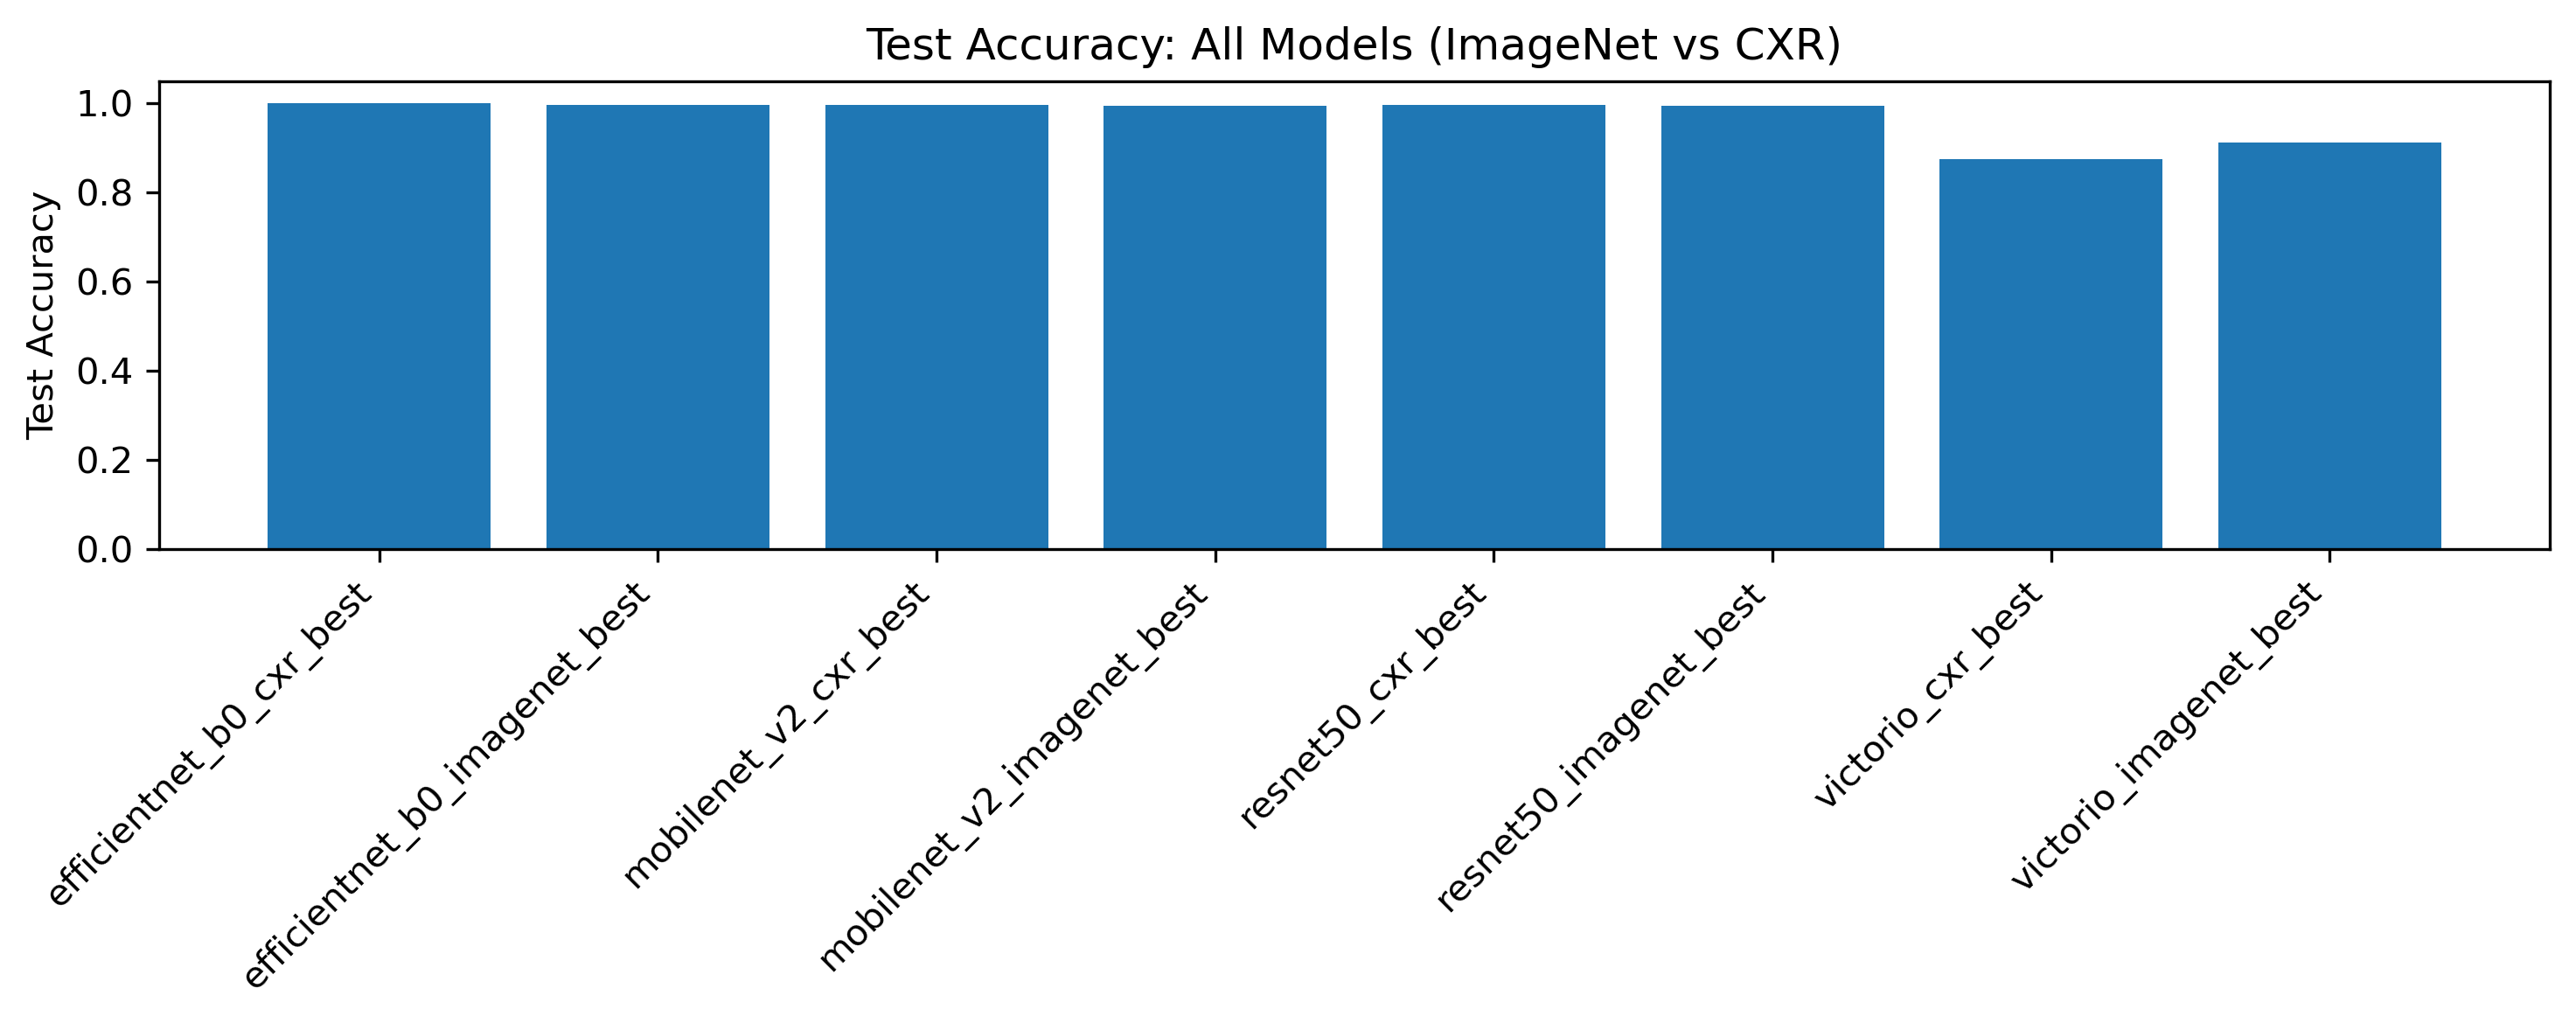

In [9]:
# Bar chart of test accuracy for a quick check.
labels = list(summary.keys())
accs = [summary[k]["accuracy"] for k in labels]

plt.figure(figsize=(10, 4))
plt.bar(range(len(labels)), accs)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy: All Models (ImageNet vs CXR)")
plt.tight_layout()

out_png = FIG_DIR / "test_accuracy_all_models.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.close()
print("Saved figure:", out_png.relative_to(PROJECT_ROOT))

# Display the final test accuracy plot directly in the notebook.
from IPython.display import Image, display

display(Image(filename=FIG_DIR / "test_accuracy_all_models.png"))

## 9. Confusion Matrix Comparison
Display all confusion matrices in a 2×4 grid layout to compare model performance across normalisation domains.  
Arrange ImageNet-based models on the top row and CXR-based models on the bottom row for direct visual comparison.  
Each matrix illustrates class-specific performance, highlighting which categories were most frequently misclassified.
#### Rationale:
- Provide a structured visual overview of model confusion across all architectures.  
- Enable direct comparison between ImageNet-initialised and CXR-trained variants.  
- Identify systematic misclassifications and potential data-driven biases.  
- Support qualitative interpretation of quantitative metrics presented earlier.

Composite grid saved to: reports/figures/confusion_matrix_grid_2x4.png


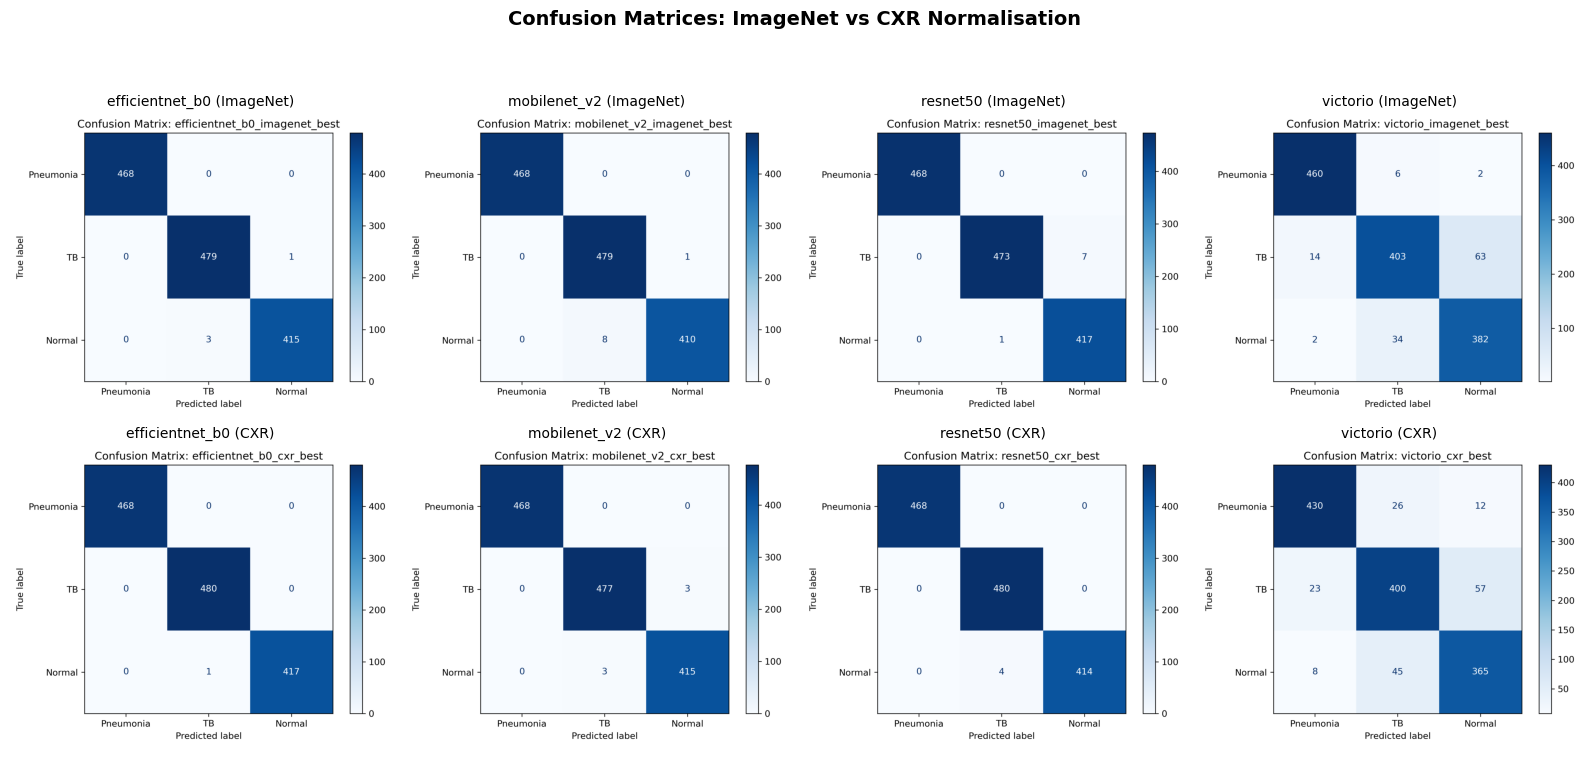

In [10]:
# Visualise All Confusion Matrices in Grid Layout
import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Collect all confusion matrix images from the reports/figures folder.
confusion_paths = sorted(FIG_DIR.glob("*_confusion_matrix.png"))
if not confusion_paths:
    raise FileNotFoundError("No confusion matrix PNG files found in reports/figures.")

# Separate into ImageNet and CXR variants.
imagenet_paths = sorted([p for p in confusion_paths if "imagenet" in p.stem])
cxr_paths      = sorted([p for p in confusion_paths if "cxr" in p.stem])

# Sanity check: both should contain the same 4 model names.
if len(imagenet_paths) != len(cxr_paths):
    print(f'Warning: Unequal number of ImageNet ({len(imagenet_paths)}) and CXR ({len(cxr_paths)}) matrices detected.')

# Create grid: 2 rows (normalisation) × 4 columns (architectures).
fig, axes = plt.subplots(2, len(imagenet_paths), figsize=(16, 8))
fig.suptitle("Confusion Matrices: ImageNet vs CXR Normalisation", fontsize=14, weight="bold")

# Top Row: ImageNet.
for j, path in enumerate(imagenet_paths):
    img = PILImage.open(path)
    axes[0, j].imshow(img)
    model_name = path.stem.replace("_imagenet_best_confusion_matrix", "")
    axes[0, j].set_title(f'{model_name} (ImageNet)', fontsize=10)
    axes[0, j].axis("off")

# Bottom Row: CXR.
for j, path in enumerate(cxr_paths):
    img = PILImage.open(path)
    axes[1, j].imshow(img)
    model_name = path.stem.replace("_cxr_best_confusion_matrix", "")
    axes[1, j].set_title(f"{model_name} (CXR)", fontsize=10)
    axes[1, j].axis("off")

# Adjust spacing and show final grid.
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save BEFORE showing. This avoids clearing the figure.
out_path = FIG_DIR / "confusion_matrix_grid_2x4.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Composite grid saved to: {out_path.relative_to(PROJECT_ROOT)}")

plt.show()